# Arbitrary angle scheme based on [[4,1,1,2]]-code

|+> state prep -> ZZ rotation gate (check the case of phi=0 and np.pi/2) -> ZX-QED -> ideal measurement + decoding


In [1]:
import stim
import numpy as np
import scipy as sp
import sinter  # used for Monte Carlo sampling
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

### Case I: $\phi=0$

Pauli error channel is imported from the program `ZZphi_gate.ipynb`


In [2]:
# import the ZZ-rot Pauli error channel fitting parameters

import pickle

# Load the fitting parameters
with open("fitting_parameters_phi_0.pkl", "rb") as f:
    loaded_parameters = pickle.load(f)

# Access the fitting parameters for a specific Pauli operator
pauli = "II"
params = loaded_parameters[pauli]
shape = params["shape"]
coefficients = params["coefficients"]

# Print or use the fitting parameters
print(f"Fitting parameters for {pauli}: Shape = {shape}, Coefficients = {coefficients}")

# # Example: Reconstruct the fitting curve
# if shape == "linear":
#     fit_curve = 1 - coefficients[0] * kappa0List  # For II
#     # fit_curve = coefficients[0] * kappa0List  # For IX, IY, etc.
# elif shape == "quadratic":
#     fit_curve = coefficients[0] * kappa0List**2  # For XX, XY, etc.

Fitting parameters for II: Shape = linear, Coefficients = [4.21343646]


In [3]:
# subcircuit definition
def ZX_QED_4112(circuit:stim.Circuit, Ind0_4112:int, rec_g:int, p_dep:float) -> tuple[stim.Circuit, int, int]:
    '''
    ZX_QED circuit as a subroutine.
    The gauge detector location rec_g < 0 is used and updated. 
    If rec_g = 0, then the Z gauge value is known to be a fixed value 0
    '''

    # counter for the number of measurements in the subroutine
    numM = 0

    ## 4112 1-FT ZX-QED procedure: detector 1,2,3
    circuit.append("R", [x+Ind0_4112 for x in [0,1]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep) 
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [2,0,4,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [2,0,4,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [3,5]], p_dep)
    circuit.append("R", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [3,0,5,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [3,0,5,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,4]], p_dep)
    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)  # measurement error
    if rec_g == 0:
        circuit.append("M", [x+Ind0_4112 for x in [0,1]])
        circuit.append("DETECTOR", [stim.target_rec(x) for x in [-2]])  # gauge Z operator detector: should be 0
    else:
        circuit.append("M", [x+Ind0_4112 for x in [0,1]])
        rec_g = rec_g - 2
        circuit.append("DETECTOR", [stim.target_rec(x) for x in [-2, rec_g]])  # gauge Z operator detector: should be 0
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SZ stabilizer: should be 0
    circuit.append("CNOT", [x+Ind0_4112 for x in [6,2,7,3]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,2,7,3]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [4,5]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,4,7,5]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,4,7,5]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3]], p_dep)
    circuit.append("TICK")

    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep) # H gate error
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep) # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [6,7]])
    rec_g = -2  # reset the location of gauge detector
    numM = numM +2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SX stabilizer: should be 0
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    return circuit, rec_g, numM


def XZ_QED_4112(circuit:stim.Circuit, Ind0_4112:int, rec_g:int, p_dep:float) -> tuple[stim.Circuit, int, int]:
    '''
    XZ_QED circuit as a subroutine.
    The gauge detector location rec_g < 0 is used and updated. 
    If rec_g = 0, then the Z gauge value is known to be a fixed value 0
    '''
    
    numM = 0

    circuit.append("R", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,2,7,3]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,2,7,3]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [4,5]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,4,7,5]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,4,7,5]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3]], p_dep)
    circuit.append("R", [x+Ind0_4112 for x in [0,1]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [2,0,4,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [2,0,4,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [3,5]], p_dep)
    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [3,0,5,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [3,0,5,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,4]], p_dep)
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)  # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [6,7]])
    if rec_g == 0:   # the gauge X operator is fixed at the beginning
        circuit.append("DETECTOR",[stim.target_rec(x) for x in [-2]])
    else:   # the gauge X is determined by former measurements
        rec_g = rec_g - 2
        # rec_MZZlast = rec_MZZlast - 2
        circuit.append("DETECTOR",[stim.target_rec(x) for x in [-2, rec_g]])  # gauge X operator detector: should be the same as first measurement
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SX stabilizer: should be 0
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)  # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [0,1]])
    # rec_MZZlast = rec_MZZlast - 2
    rec_g = -2
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SZ stabilizer: should be 0
    circuit.append("TICK")
    
    return circuit, rec_g, numM

In [6]:
# create a function to generate circuits with given error rate
def PlusPrep_ZXQEDCirc_4112(p_dep:float, Ind0_4112:int = 0, basis:int = 0) -> stim.Circuit:
    ''' 
    basis: 0: X-basis; 1: Z-basis; (2: Y-basis)
    '''
    # circuit initialization
    N = 8   # number of qubits in the circuit
    qubits = np.array(range(8))
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    # Ind0_4112 = 0;  # the start qubit index : will be used if then put the whole circuit as a subroutine for some other applications

    # noise parameter setting:
    # p_dep = 0.001    # depolarizing error rate: for both single- and two-qubit gates

    # initial state preparation
    match basis:
        case 0: # X-basis
            # 1-FT state preparation without measurement
            circ0 = stim.Circuit()
            # reset the data qubits0
            circ0.append("R", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
            circ0.append("TICK")   # for synchronizing the circuit, no real use

            # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
            circ0.append("H", [x+Ind0_4112 for x in [data[0], data[2]]] )  # D0 and D2 add Hadamard
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
            circ0.append("CNOT", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in data], p_dep) 
            circ0.append("TICK")
        case 1: # Z-basis
            # 1-FT state preparation without measurement
            circ0 = stim.Circuit()
            # reset the data qubits0
            circ0.append("R", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
            circ0.append("TICK")   # for synchronizing the circuit, no real use

            # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
            circ0.append("H", [x+Ind0_4112 for x in [data[0], data[1]]] )  # D0 and D2 add Hadamard
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
            circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2], data[1], data[3]] ])
            circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in [data[0], data[2], data[1], data[3]]], p_dep) 
            circ0.append("TICK")
        # case 2: # Y-basis: after the X-basis preparation: add an extra noiseless S gate   (Problematic!!!)
        #     # 1-FT state preparation without measurement
        #     circ0 = stim.Circuit()
        #     # reset the data qubits0
        #     circ0.append("R", [x+Ind0_4112 for x in data])
        #     circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
        #     circ0.append("TICK")   # for synchronizing the circuit, no real use

        #     # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
        #     circ0.append("H", [x+Ind0_4112 for x in [data[0], data[2]]] )  # D0 and D2 add Hadamard
        #     circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
        #     circ0.append("CNOT", [x+Ind0_4112 for x in data])
        #     circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in data], p_dep) 
        #     circ0.append("TICK")

        #     # extra noiseless logical S gate
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
        #     circ0.append("S", data[2]+Ind0_4112 )
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )


    # ZZ-rotation: trivial rotation with given two-qubit Pauli channel
    # Define the Pauli operators for labeling
    pauli_operators = [
        "IX", "IY", "IZ", "XI", "XX", "XY", "XZ", "YI", "YX", "YY", "YZ", "ZI", "ZX", "ZY", "ZZ"
    ]   # no identity term

    pauli_error_vector = np.zeros(15) # register for Pauli error rates

    for id_pauli, pauli in enumerate(pauli_operators):
        params = loaded_parameters[pauli]
        shape = params["shape"]
        coefficients = params["coefficients"]
        if shape == "linear":
            pauli_error_vector[id_pauli] = coefficients[0]*p_dep
        elif shape == "quadratic":
            pauli_error_vector[id_pauli] = coefficients[0]*(p_dep**2)
        else:
            print("Error!")
            exit()

    circ0.append("PAULI_CHANNEL_2", [x+Ind0_4112 for x in [data[0], data[2]]], pauli_error_vector)  # D0 and D2 rotation gate: Pauli errors

    # erasure error
    params = loaded_parameters["Pfail"]
    shape = params["shape"]
    coefficients = params["coefficients"]
    if shape == "linear":
        pfail = coefficients[0]*p_dep
    elif shape == "quadratic":
        pfail = coefficients[0]*(p_dep**2)
    else:
        print("Error!")
        exit()

    circ0.append("HERALDED_ERASE", data[0]+Ind0_4112, pfail)
    circ0.append("DETECTOR", stim.target_rec(-1))
    circ0.append("TICK")

    # 1-FT QED procedure
    match basis:
        case 0: # X-basis 
            # ZX-QED: rec_g = 0
            rec_g = 0
            circ0, rec_g, numM = ZX_QED_4112(circ0, Ind0_4112, rec_g, p_dep)
        case 1: # Z-basis
            # XZ-QED: rec_g = 0
            rec_g = 0
            circ0, rec_g, numM = XZ_QED_4112(circ0, Ind0_4112, rec_g, p_dep)


    # noiseless transversal logical measurement + error detection
    match basis:
        case 0: # X-basis
            # check the error rate: adding ideal measurement + ideal decoding
            circ0.append("H", [x+Ind0_4112 for x in data])
            circ0.append("M",[x+Ind0_4112 for x in data])
            circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SX stabilizer detector: should be 0
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-3,-5] ])  # gX gauge check detector: should be 0
            circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-3),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator
        case 1: # Z-basis
            # check the error rate: adding ideal measurement + ideal decoding
            circ0.append("M",[x+Ind0_4112 for x in data])
            circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SZ stabilizer detector: should be 0
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2,-5] ])  # gZ gauge check detector: should be 0
            circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-2),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator
        # case 2: # Y-basis: before the transversal X-basis preparation: add an extra noiseless logical S^dag gate
        #     # extra noiseless logical S gate
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
        #     circ0.append("S_DAG", data[2]+Ind0_4112 )
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )

        #     # check the error rate: adding ideal measurement + ideal decoding
        #     circ0.append("H", [x+Ind0_4112 for x in data])
        #     circ0.append("M",[x+Ind0_4112 for x in data])
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SX stabilizer detector: should be 0
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-3,-5] ])  # gX gauge check detector: should be 0
        #     circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-3),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator
            
    return circ0

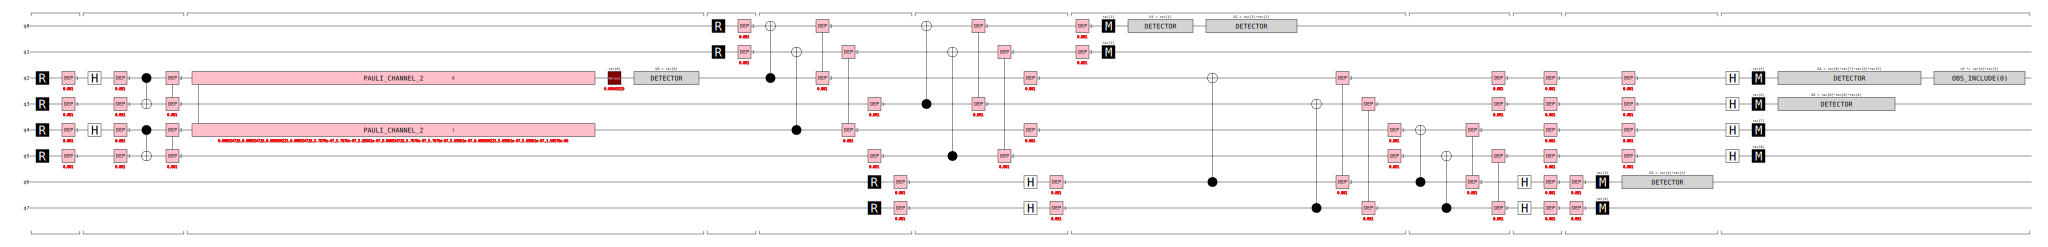

In [7]:
circ0 = PlusPrep_ZXQEDCirc_4112(0.001, 0, 0)

diagram = circ0.diagram('timeline-svg')
with open('4112ZXQED.svg', 'w') as f:
    print(diagram, file=f)

circ0.diagram('timeline-svg')

In [8]:
# logical error counter for |+> state prep + teleportation circuit
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> tuple[int, int]:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    # detector_error_model = circuit.detector_error_model(decompose_errors=True)
    # matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    # predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    # num_errors = 0
    # for shot in range(num_shots):
    #     actual_for_shot = observable_flips[shot]
    #     predicted_for_shot = predictions[shot]
    #     if not np.array_equal(actual_for_shot, predicted_for_shot):
    #         num_errors += 1
    # return num_errors

    # for 4112 code, no decoder is used: we post-select data based on the syndromes
    num_detects = 0
    num_errors = 0
    for shot in range(num_shots):
        # check all the detectors: discard the round if exist "1" outcome 
        if not any(detection_events[shot,:]):
            num_detects += 1
            if observable_flips[shot]:  # if observable_flips= true, then error occurs
                num_errors += 1
    return (num_detects, num_errors)

In [8]:
# check one data point
num_shots = int(1e5)
num_detects, num_errors = count_logical_errors(circ0, num_shots)

print (f"Shot number:{num_shots}, effective shot number:{num_detects}, shots with logical error:{num_errors}.")

Shot number:100000, effective shot number:95552, shots with logical error:5.


#### Sweep the error rates: calculate the X, Z errors, get the averaged error rates and failure probability

Follow the google paper [Nature 638, 920–926 (2025)], we define the average error rate $\epsilon_d: = 0.5* (f_x + f_z)$ over X and Z eigenstates. 

Because $2\epsilon_d = f_x + f_z = (p_z + p_y) + (p_x + p_y) \geq (p_x + p_y + p_z)$, we can use $2\epsilon_d$ as an upper bound of the total logical error rate.


In [9]:
# Function to simulate the circuit and calculate the Failure Probability and logical error rate
def simulate_circuit(p_values):
    failure_probabilities_X = []
    failure_prob_bars_X = []

    logical_error_rates_X = []
    logical_error_bars_X = []

    logical_error_rates_Z = []
    logical_error_bars_Z = []
    
    for p_dep in p_values:
        # Dynamically set the number of samples based on the error rate
        if p_dep > 7e-3:
            shots = int(1e6)  # Fewer shots for larger error rates
        elif 5e-4 < p_dep <= 7e-3:
            shots = int(3e7)  # Intermediate number of shots
        else:
            shots = int(5e7)  # Maximum number of shots for smallest error rates

        # shots = int(1e6)

        # Generate X-basis circuit
        circuit = PlusPrep_ZXQEDCirc_4112(p_dep, 0, 0)
        
        # count the number of successful shots and and error shots
        num_detects, num_errors = count_logical_errors(circuit, shots)

        # Failure probability: where the detector reports no error
        failure_probability_X = 1 - (num_detects / shots)
        failure_probabilities_X.append(failure_probability_X)
        
        # X-basis logical error rate: based on the observable's measurement outcomes
        logical_error_rate_X = num_errors / num_detects
        logical_error_rates_X.append(logical_error_rate_X)
        
        # Error bars using binomial distribution (standard deviation)
        failure_std = np.sqrt(failure_probability_X * (1 - failure_probability_X) / shots)
        logical_error_std_X = np.sqrt(logical_error_rate_X * (1 - logical_error_rate_X) / num_detects)
        
        failure_prob_bars_X.append(failure_std)
        logical_error_bars_X.append(logical_error_std_X)


        # Generate Z-basis circuit
        circuit = PlusPrep_ZXQEDCirc_4112(p_dep, 0, 1)
        
        # count the number of successful shots and and error shots
        num_detects, num_errors = count_logical_errors(circuit, shots)
        
        # X-basis logical error rate: based on the observable's measurement outcomes
        logical_error_rate_Z = num_errors / num_detects
        logical_error_rates_Z.append(logical_error_rate_Z)
        
        # Error bars using binomial distribution (standard deviation)
        logical_error_std_Z = np.sqrt(logical_error_rate_Z * (1 - logical_error_rate_Z) / num_detects)
        
        logical_error_bars_Z.append(logical_error_std_Z)

    
    return failure_probabilities_X, failure_prob_bars_X, logical_error_rates_X, logical_error_bars_X, logical_error_rates_Z, logical_error_bars_Z

In [30]:
# Define the range of physical error rates (log scale)
p_values = np.logspace(-4, -2, num=30)
Ind0_4112 = 0

# Simulate the circuit for different error rates
failure_probabilities_X_I, failure_prob_bars_X_I, logical_error_rates_X_I, logical_error_bars_X_I, logical_error_rates_Z_I, logical_error_bars_Z_I = simulate_circuit(p_values)

# # Plot success probabilities with shaded error bars
# plt.figure()
# plt.plot(p_values, failure_probabilities_X_S, label='Failure Probability', color='green')
# plt.fill_between(p_values, 
#                  np.array(failure_probabilities_X_S) - np.array(failure_prob_bars_X_S), 
#                  np.array(failure_probabilities_X_S) + np.array(failure_prob_bars_X_S), 
#                  color='green', alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Physical Error Rate (p_dep)')
# plt.ylabel('Failure Probability')
# plt.title('Failure Probability vs Physical Error Rate')
# plt.grid(True, which="both", ls="--")
# plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
# plt.legend()
# plt.show()

# # Plot logical error rates with shaded error bars

# # overall standard deviation of the summation of the logical error rates
# logical_error_bars = np.sqrt( np.array(logical_error_bars_X_S)**2 + np.array(logical_error_bars_Z_S)**2 )  # estimate the upper bound of the standard deviation
# logical_error_rates = np.array(logical_error_rates_X_S) + np.array(logical_error_bars_Z_S)

# plt.figure()
# plt.plot(p_values, logical_error_rates, label='Logical Error Rate', color='red')
# plt.fill_between(p_values, 
#                  np.array(logical_error_rates) - np.array(logical_error_bars), 
#                  np.array(logical_error_rates) + np.array(logical_error_bars), 
#                  color='red', alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Physical Error Rate (p_dep)')
# plt.ylabel('Logical Error Rate')
# plt.title('Logical Error Rate vs Physical Error Rate')
# plt.grid(True, which="both", ls="--")
# plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
# plt.legend()
# plt.show()

### Case II: $\phi=\pi/4$

Pauli error channel is imported from the program `ZZphi_gate.ipynb`


In [10]:
# import the ZZ-rot Pauli error channel fitting parameters

import pickle

# Load the fitting parameters
with open("fitting_parameters_phi_piover4.pkl", "rb") as f:
    loaded_parameters = pickle.load(f)

# Access the fitting parameters for a specific Pauli operator
pauli = "II"
params = loaded_parameters[pauli]
shape = params["shape"]
coefficients = params["coefficients"]

# Print or use the fitting parameters
print(f"Fitting parameters for {pauli}: Shape = {shape}, Coefficients = {coefficients}")

# # Example: Reconstruct the fitting curve
# if shape == "linear":
#     fit_curve = 1 - coefficients[0] * kappa0List  # For II
#     # fit_curve = coefficients[0] * kappa0List  # For IX, IY, etc.
# elif shape == "quadratic":
#     fit_curve = coefficients[0] * kappa0List**2  # For XX, XY, etc.

Fitting parameters for II: Shape = linear, Coefficients = [4.35581687]


In [32]:
# subcircuit definition
def ZX_QED_4112(circuit:stim.Circuit, Ind0_4112:int, rec_g:int, p_dep:float) -> tuple[stim.Circuit, int, int]:
    '''
    ZX_QED circuit as a subroutine.
    The gauge detector location rec_g < 0 is used and updated. 
    If rec_g = 0, then the Z gauge value is known to be a fixed value 0
    '''

    # counter for the number of measurements in the subroutine
    numM = 0

    ## 4112 1-FT ZX-QED procedure: detector 1,2,3
    circuit.append("R", [x+Ind0_4112 for x in [0,1]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep) 
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [2,0,4,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [2,0,4,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [3,5]], p_dep)
    circuit.append("R", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [3,0,5,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [3,0,5,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,4]], p_dep)
    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)  # measurement error
    if rec_g == 0:
        circuit.append("M", [x+Ind0_4112 for x in [0,1]])
        circuit.append("DETECTOR", [stim.target_rec(x) for x in [-2]])  # gauge Z operator detector: should be 0
    else:
        circuit.append("M", [x+Ind0_4112 for x in [0,1]])
        rec_g = rec_g - 2
        circuit.append("DETECTOR", [stim.target_rec(x) for x in [-2, rec_g]])  # gauge Z operator detector: should be 0
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SZ stabilizer: should be 0
    circuit.append("CNOT", [x+Ind0_4112 for x in [6,2,7,3]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,2,7,3]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [4,5]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,4,7,5]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,4,7,5]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3]], p_dep)
    circuit.append("TICK")

    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep) # H gate error
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep) # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [6,7]])
    rec_g = -2  # reset the location of gauge detector
    numM = numM +2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SX stabilizer: should be 0
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    return circuit, rec_g, numM


def XZ_QED_4112(circuit:stim.Circuit, Ind0_4112:int, rec_g:int, p_dep:float) -> tuple[stim.Circuit, int, int]:
    '''
    XZ_QED circuit as a subroutine.
    The gauge detector location rec_g < 0 is used and updated. 
    If rec_g = 0, then the Z gauge value is known to be a fixed value 0
    '''
    
    numM = 0

    circuit.append("R", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,2,7,3]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,2,7,3]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [4,5]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [6,4,7,5]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [6,4,7,5]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3]], p_dep)
    circuit.append("R", [x+Ind0_4112 for x in [0,1]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [2,0,4,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [2,0,4,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [3,5]], p_dep)
    circuit.append("H", [x+Ind0_4112 for x in [6,7]])
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)
    circuit.append("TICK")

    circuit.append("CNOT", [x+Ind0_4112 for x in [3,0,5,1]])
    circuit.append("DEPOLARIZE2", [x+Ind0_4112 for x in [3,0,5,1]], p_dep) 
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,4]], p_dep)
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [6,7]], p_dep)  # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [6,7]])
    if rec_g == 0:   # the gauge X operator is fixed at the beginning
        circuit.append("DETECTOR",[stim.target_rec(x) for x in [-2]])
    else:   # the gauge X is determined by former measurements
        rec_g = rec_g - 2
        # rec_MZZlast = rec_MZZlast - 2
        circuit.append("DETECTOR",[stim.target_rec(x) for x in [-2, rec_g]])  # gauge X operator detector: should be the same as first measurement
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SX stabilizer: should be 0
    circuit.append("TICK")

    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [2,3,4,5]], p_dep) # idling error
    circuit.append("DEPOLARIZE1", [x+Ind0_4112 for x in [0,1]], p_dep)  # measurement error
    circuit.append("M", [x+Ind0_4112 for x in [0,1]])
    # rec_MZZlast = rec_MZZlast - 2
    rec_g = -2
    numM = numM + 2
    circuit.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SZ stabilizer: should be 0
    circuit.append("TICK")
    
    return circuit, rec_g, numM

In [ ]:
# create a function to generate circuits with given error rate
def PlusPrep_ZXQEDCirc_4112(p_dep:float, Ind0_4112:int = 0, basis:int = 0) -> stim.Circuit:
    ''' 
    basis: 0: X-basis; 1: Z-basis; (2: Y-basis)
    '''
    # circuit initialization
    N = 8   # number of qubits in the circuit
    qubits = np.array(range(8))
    data = qubits[2:6]   # 4 qubits in the middle: data
    ancilla = qubits[np.r_[0:2,6:8]]   # 4 qubits on both sides: ancilla
    # Ind0_4112 = 0;  # the start qubit index : will be used if then put the whole circuit as a subroutine for some other applications

    # noise parameter setting:
    # p_dep = 0.001    # depolarizing error rate: for both single- and two-qubit gates

    # initial state preparation
    match basis:
        case 0: # X-basis
            # 1-FT state preparation without measurement
            circ0 = stim.Circuit()
            # reset the data qubits0
            circ0.append("R", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
            circ0.append("TICK")   # for synchronizing the circuit, no real use

            # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
            circ0.append("H", [x+Ind0_4112 for x in [data[0], data[2]]] )  # D0 and D2 add Hadamard
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
            circ0.append("CNOT", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in data], p_dep) 
            circ0.append("TICK")
        case 1: # Z-basis
            # 1-FT state preparation without measurement
            circ0 = stim.Circuit()
            # reset the data qubits0
            circ0.append("R", [x+Ind0_4112 for x in data])
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
            circ0.append("TICK")   # for synchronizing the circuit, no real use

            # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
            circ0.append("H", [x+Ind0_4112 for x in [data[0], data[1]]] )  # D0 and D2 add Hadamard
            circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
            circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2], data[1], data[3]] ])
            circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in [data[0], data[2], data[1], data[3]]], p_dep) 
            circ0.append("TICK")
        # case 2: # Y-basis: after the X-basis preparation: add an extra noiseless S gate   (Problematic!!!)
        #     # 1-FT state preparation without measurement
        #     circ0 = stim.Circuit()
        #     # reset the data qubits0
        #     circ0.append("R", [x+Ind0_4112 for x in data])
        #     circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # data state preparation error
        #     circ0.append("TICK")   # for synchronizing the circuit, no real use

        #     # prepare two Bell pairs: should be 1-FT; the gauge qubit is prepared to 0 state
        #     circ0.append("H", [x+Ind0_4112 for x in [data[0], data[2]]] )  # D0 and D2 add Hadamard
        #     circ0.append("DEPOLARIZE1", [x+Ind0_4112 for x in data], p_dep) # both H and idling experience error
        #     circ0.append("CNOT", [x+Ind0_4112 for x in data])
        #     circ0.append("DEPOLARIZE2", [x+Ind0_4112 for x in data], p_dep) 
        #     circ0.append("TICK")

        #     # extra noiseless logical S gate
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
        #     circ0.append("S", data[2]+Ind0_4112 )
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )


    # ZZ-rotation: np.pi/4-rotation with given two-qubit Pauli channel: logical S gate
    # first implement the "noiseless" S gate
    # extra noiseless logical S gate
    circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
    circ0.append("S", data[2]+Ind0_4112 )
    circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )

    # then append the noise channel
    # Define the Pauli operators for labeling
    pauli_operators = [
        "IX", "IY", "IZ", "XI", "XX", "XY", "XZ", "YI", "YX", "YY", "YZ", "ZI", "ZX", "ZY", "ZZ"
    ]   # no identity term

    pauli_error_vector = np.zeros(15) # register for Pauli error rates

    for id_pauli, pauli in enumerate(pauli_operators):
        params = loaded_parameters[pauli]
        shape = params["shape"]
        coefficients = params["coefficients"]
        if shape == "linear":
            pauli_error_vector[id_pauli] = coefficients[0]*p_dep
        elif shape == "quadratic":
            pauli_error_vector[id_pauli] = coefficients[0]*(p_dep**2)
        else:
            print("Error!")
            exit()

    circ0.append("PAULI_CHANNEL_2", [x+Ind0_4112 for x in [data[0], data[2]]], pauli_error_vector)  # D0 and D2 rotation gate: Pauli errors

    # erasure error
    params = loaded_parameters["Pfail"]
    shape = params["shape"]
    coefficients = params["coefficients"]
    if shape == "linear":
        pfail = coefficients[0]*p_dep
    elif shape == "quadratic":
        pfail = coefficients[0]*(p_dep**2)
    else:
        print("Error!")
        exit()

    circ0.append("HERALDED_ERASE", data[0]+Ind0_4112, pfail)
    circ0.append("DETECTOR", stim.target_rec(-1))
    circ0.append("TICK")

    # 1-FT QED procedure
    match basis:
        case 0: # X-basis 
            # ZX-QED: rec_g = 0
            rec_g = 0
            circ0, rec_g, numM = ZX_QED_4112(circ0, Ind0_4112, rec_g, p_dep)
        case 1: # Z-basis
            # XZ-QED: rec_g = 0
            rec_g = 0
            circ0, rec_g, numM = XZ_QED_4112(circ0, Ind0_4112, rec_g, p_dep)


    # noiseless transversal logical measurement + error detection

    # # # first perform a noiseless S_dag gate
    # circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
    # circ0.append("S_DAG", data[2]+Ind0_4112 )
    # circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )

    match basis:
        case 0: # X-basis
            # now should measure in Y-basis
            # no transversal measurement in this case!
            # we perform an ideal 4112 QED first, then perform non-transversal Y measurement by (Y,X;Z,I)
            circ0.append("R", [x+Ind0_4112 for x in [6,7]])
            circ0.append("H", [x+Ind0_4112 for x in [6,7]])
            circ0.append("CNOT", [x+Ind0_4112 for x in [6,2,7,3]])
            circ0.append("CNOT", [x+Ind0_4112 for x in [6,4,7,5]])

            circ0.append("R", [x+Ind0_4112 for x in [0,1]])
            circ0.append("CNOT", [x+Ind0_4112 for x in [2,0,4,1]])
            circ0.append("H", [x+Ind0_4112 for x in [6,7]])
            circ0.append("CNOT", [x+Ind0_4112 for x in [3,0,5,1]])
            circ0.append("M", [x+Ind0_4112 for x in [6,7]])
            rec_g = rec_g - 2
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-2, rec_g]])  # gauge gX check: should be 0
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SX stabilizer: should be 0

            circ0.append("M", [x+Ind0_4112 for x in [0,1]])
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2]])  # SZ stabilizer: should be 0

            # non-transversal Y measurement by (Y,X;Z,I)
            circ0.append("S_DAG", [x+Ind0_4112 for x in [2]])
            circ0.append("H", [x+Ind0_4112 for x in [2,3]])
            circ0.append("M", [x+Ind0_4112 for x in data])
            circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-4),stim.target_rec(-3),stim.target_rec(-2)], 0)  # logical Y outcome: should be 1; the logical error estimator
        
        
        
        # # check the error rate: adding ideal measurement + ideal decoding
        #     circ0.append("H", [x+Ind0_4112 for x in data])
        #     circ0.append("M",[x+Ind0_4112 for x in data])
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SX stabilizer detector: should be 0
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-3,-5] ])  # gX gauge check detector: should be 0
        #     circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-3),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator

        case 1: # Z-basis
            # check the error rate: adding ideal measurement + ideal decoding
            circ0.append("M",[x+Ind0_4112 for x in data])
            circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SZ stabilizer detector: should be 0
            circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-2,-5] ])  # gZ gauge check detector: should be 0
            circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-2),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator
        # case 2: # Y-basis: before the transversal X-basis preparation: add an extra noiseless logical S^dag gate
        #     # extra noiseless logical S gate
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )
        #     circ0.append("S_DAG", data[2]+Ind0_4112 )
        #     circ0.append("CNOT", [x+Ind0_4112 for x in [data[0], data[2]]] )

        #     # check the error rate: adding ideal measurement + ideal decoding
        #     circ0.append("H", [x+Ind0_4112 for x in data])
        #     circ0.append("M",[x+Ind0_4112 for x in data])
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in range(-1,-5,-1)])  # SX stabilizer detector: should be 0
        #     circ0.append("DETECTOR",[stim.target_rec(x) for x in [-1,-3,-5] ])  # gX gauge check detector: should be 0
        #     circ0.append("OBSERVABLE_INCLUDE",[stim.target_rec(-3),stim.target_rec(-4)],0)  # logical X outcome: should be 0; the logical error estimator
            
    return circ0

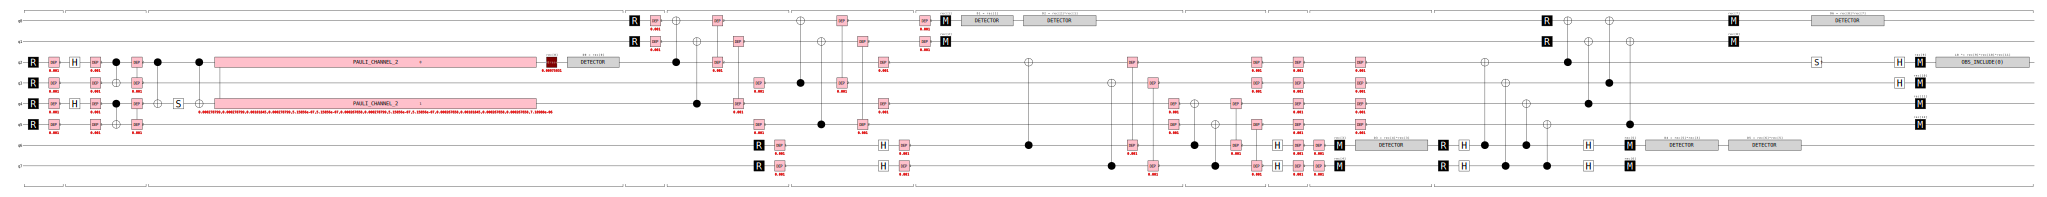

In [34]:
circ0 = PlusPrep_ZXQEDCirc_4112(0.001, 0, 0)

diagram = circ0.diagram('timeline-svg')
with open('4112ZXQED.svg', 'w') as f:
    print(diagram, file=f)

circ0.diagram('timeline-svg')

In [35]:
# logical error counter for |+> state prep + teleportation circuit
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> tuple[int, int]:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    # detector_error_model = circuit.detector_error_model(decompose_errors=True)
    # matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    # predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    # num_errors = 0
    # for shot in range(num_shots):
    #     actual_for_shot = observable_flips[shot]
    #     predicted_for_shot = predictions[shot]
    #     if not np.array_equal(actual_for_shot, predicted_for_shot):
    #         num_errors += 1
    # return num_errors

    # for 4112 code, no decoder is used: we post-select data based on the syndromes
    num_detects = 0
    num_errors = 0
    for shot in range(num_shots):
        # check all the detectors: discard the round if exist "1" outcome 
        if not any(detection_events[shot,:]):
            num_detects += 1
            if observable_flips[shot]:  # if observable_flips= true, then error occurs
                num_errors += 1
    return (num_detects, num_errors)

In [36]:
# check one data point
num_shots = int(1e6)
num_detects, num_errors = count_logical_errors(circ0, num_shots)

print (f"Shot number:{num_shots}, effective shot number:{num_detects}, shots with logical error:{num_errors}.")

Shot number:1000000, effective shot number:949002, shots with logical error:34.


#### Sweep the error rates: calculate the X, Z errors, get the averaged error rates and failure probability

Follow the google paper [Nature 638, 920–926 (2025)], we define the average error rate $\epsilon_d: = 0.5* (f_x + f_z)$ over X and Z eigenstates. 

Because $2\epsilon_d = f_x + f_z = (p_z + p_y) + (p_x + p_y) \geq (p_x + p_y + p_z)$, we can use $2\epsilon_d$ as an upper bound of the total logical error rate.


In [37]:
# Function to simulate the circuit and calculate the Failure Probability and logical error rate
def simulate_circuit(p_values):
    failure_probabilities_X = []
    failure_prob_bars_X = []

    logical_error_rates_X = []
    logical_error_bars_X = []

    logical_error_rates_Z = []
    logical_error_bars_Z = []
    
    for p_dep in p_values:
        # Dynamically set the number of samples based on the error rate
        if p_dep > 7e-3:
            shots = int(1e6)  # Fewer shots for larger error rates
        elif 5e-4 < p_dep <= 7e-3:
            shots = int(3e7)  # Intermediate number of shots
        else:
            shots = int(5e7)  # Maximum number of shots for smallest error rates

        # shots = int(1e6)

        # Generate X-basis circuit
        circuit = PlusPrep_ZXQEDCirc_4112(p_dep, 0, 0)
        
        # count the number of successful shots and and error shots
        num_detects, num_errors = count_logical_errors(circuit, shots)

        # Failure probability: where the detector reports no error
        failure_probability_X = 1 - (num_detects / shots)
        failure_probabilities_X.append(failure_probability_X)
        
        # X-basis logical error rate: based on the observable's measurement outcomes
        logical_error_rate_X = num_errors / num_detects
        logical_error_rates_X.append(logical_error_rate_X)
        
        # Error bars using binomial distribution (standard deviation)
        failure_std = np.sqrt(failure_probability_X * (1 - failure_probability_X) / shots)
        logical_error_std_X = np.sqrt(logical_error_rate_X * (1 - logical_error_rate_X) / num_detects)
        
        failure_prob_bars_X.append(failure_std)
        logical_error_bars_X.append(logical_error_std_X)


        # Generate Z-basis circuit
        circuit = PlusPrep_ZXQEDCirc_4112(p_dep, 0, 1)
        
        # count the number of successful shots and and error shots
        num_detects, num_errors = count_logical_errors(circuit, shots)
        
        # X-basis logical error rate: based on the observable's measurement outcomes
        logical_error_rate_Z = num_errors / num_detects
        logical_error_rates_Z.append(logical_error_rate_Z)
        
        # Error bars using binomial distribution (standard deviation)
        logical_error_std_Z = np.sqrt(logical_error_rate_Z * (1 - logical_error_rate_Z) / num_detects)
        
        logical_error_bars_Z.append(logical_error_std_Z)

    
    return failure_probabilities_X, failure_prob_bars_X, logical_error_rates_X, logical_error_bars_X, logical_error_rates_Z, logical_error_bars_Z

In [38]:
# Define the range of physical error rates (log scale)
p_values = np.logspace(-4, -2, num=30)
Ind0_4112 = 0

# Simulate the circuit for different error rates
failure_probabilities_X_S, failure_prob_bars_X_S, logical_error_rates_X_S, logical_error_bars_X_S, logical_error_rates_Z_S, logical_error_bars_Z_S = simulate_circuit(p_values)

# # Plot success probabilities with shaded error bars
# plt.figure()
# plt.plot(p_values, failure_probabilities_X_S, label='Failure Probability', color='green')
# plt.fill_between(p_values, 
#                  np.array(failure_probabilities_X_S) - np.array(failure_prob_bars_X_S), 
#                  np.array(failure_probabilities_X_S) + np.array(failure_prob_bars_X_S), 
#                  color='green', alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Physical Error Rate (p_dep)')
# plt.ylabel('Failure Probability')
# plt.title('Failure Probability vs Physical Error Rate')
# plt.grid(True, which="both", ls="--")
# plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
# plt.legend()
# plt.show()

# # Plot logical error rates with shaded error bars

# # overall standard deviation of the summation of the logical error rates
# logical_error_bars = np.sqrt( np.array(logical_error_bars_X_S)**2 + np.array(logical_error_bars_Z_S)**2 )  # estimate the upper bound of the standard deviation
# logical_error_rates = np.array(logical_error_rates_X_S) + np.array(logical_error_bars_Z_S)

# plt.figure()
# plt.plot(p_values, logical_error_rates, label='Logical Error Rate', color='red')
# plt.fill_between(p_values, 
#                  np.array(logical_error_rates) - np.array(logical_error_bars), 
#                  np.array(logical_error_rates) + np.array(logical_error_bars), 
#                  color='red', alpha=0.3)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Physical Error Rate (p_dep)')
# plt.ylabel('Logical Error Rate')
# plt.title('Logical Error Rate vs Physical Error Rate')
# plt.grid(True, which="both", ls="--")
# plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
# plt.legend()
# plt.show()

### Plot the results, fit the curves

In [5]:
# Define fitting functions
def linear_func(x, a):
    return a * x

def quadratic_func(x, c):
    return c * x**2

## Plot the failure probability

# Use only the first 10 data points for fitting
p_values_fit = p_values[:10]
failure_probabilities_X_S_fit = failure_probabilities_X_S[:10]
failure_probabilities_X_I_fit = failure_probabilities_X_I[:10]

# Perform the linear fit using the first 10 data points
popt_fail_S, _ = curve_fit(linear_func, p_values_fit, failure_probabilities_X_S_fit)
a = popt_fail_S[0]  # Extract the fitted parameter
popt_fail_I, _ = curve_fit(linear_func, p_values_fit, failure_probabilities_X_I_fit)
b = popt_fail_I[0]  # Extract the fitted parameter

# Create the fitting formula string for the legend
formula_label_S = f"Fit: ${a:.4f} \\cdot p$"
formula_label_I = f"Fit: ${b:.4f} \\cdot p$"

# Plot failure probabilities with shaded error bars
plt.figure()
plt.plot(p_values, failure_probabilities_X_I, label='$\phi = 0$', color='lightgreen')
plt.plot(p_values, failure_probabilities_X_S, label='$\phi = \pi/4$', color='green')
# Plot the linear fit using the first 10 data points and include the formula in the legend
# plt.plot(p_values, linear_func(p_values, *popt_fail_I), '--', label=formula_label_I)
plt.plot(p_values, linear_func(p_values, *popt_fail_S), '--', label=formula_label_S)
# plt.fill_between(p_values, 
#                  np.array(failure_probabilities_X_S) - np.array(failure_prob_bars_X_S), 
#                  np.array(failure_probabilities_X_S) + np.array(failure_prob_bars_X_S), 
#                  color='green', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate (p_dep)')
plt.ylabel('Failure Probability')
plt.title('Failure Probability vs Physical Error Rate')
plt.grid(True, which="both", ls="--")
plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
plt.legend()

# Save the plot as an EPS file
plt.savefig('Pfail_250315.eps', format='eps', dpi=300, bbox_inches='tight')

plt.show()


# Plot logical error rates with shaded error bars

# overall standard deviation of the summation of the logical error rates
logical_error_bars_I = np.sqrt( np.array(logical_error_bars_X_I)**2 + np.array(logical_error_bars_Z_I)**2 )  # estimate the upper bound of the standard deviation
logical_error_rates_I = np.array(logical_error_rates_X_I) + np.array(logical_error_bars_Z_I)

logical_error_bars_S = np.sqrt( np.array(logical_error_bars_X_S)**2 + np.array(logical_error_bars_Z_S)**2 )  # estimate the upper bound of the standard deviation
logical_error_rates_S = np.array(logical_error_rates_X_S) + np.array(logical_error_rates_Z_S)

# Perform the linear fit
popt_error_S, _ = curve_fit(quadratic_func, p_values, logical_error_rates_S)
a = popt_error_S[0]  # Extract the fitted parameter

popt_error_I, _ = curve_fit(quadratic_func, p_values, logical_error_rates_I)
b = popt_error_I[0]  # Extract the fitted parameter

# Create the fitting formula string for the legend
formula_label_S = f"Fit: (${a:.4f}) \cdot p^2$"
formula_label_I = f"Fit: (${b:.4f}) \cdot p^2$"

plt.figure()
plt.plot(p_values, logical_error_rates_I, label='$\phi = 0$', color='pink')
plt.plot(p_values, logical_error_rates_S, label='$\phi = \pi/4$', color='red')
# Plot the linear fit using the first 10 data points and include the formula in the legend
plt.plot(p_values, quadratic_func(p_values, *popt_error_I), '--', label=formula_label_S)
plt.plot(p_values, quadratic_func(p_values, *popt_error_S), '--', label=formula_label_I)
# plt.fill_between(p_values, 
#                  np.array(logical_error_rates_S) - np.array(logical_error_bars_S), 
#                  np.array(logical_error_rates_S) + np.array(logical_error_bars_S), 
#                  color='red', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate (p_dep)')
plt.ylabel('Logical Error Rate')
plt.title('Logical Error Rate vs Physical Error Rate')
plt.grid(True, which="both", ls="--")
plt.axvline(x = 1e-3, color = 'b', label = 'current hardware')
plt.legend()

# Save the plot as an EPS file
plt.savefig('ErrorRate_250315.eps', format='eps', dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'p_values' is not defined

#### Save data

In [53]:
# Save to a .npz file
samplenumber = {"geq 7e-3":"1e6", "5e-4 to 7e-3":"3e7", "leq 5e-4": "5e-7"} 
chi_ZZ = 2*np.pi*4.8e6    # Dispersive coupling strength
Omega = 2*np.pi*20.4e6    # g-f driving strength
np.savez('4112simu_250315.npz', failure_probabilities_X_S, failure_prob_bars_X_S, logical_error_rates_X_S, logical_error_bars_X_S, logical_error_rates_Z_S, logical_error_bars_Z_S)
np.savez('4112simu_250315.npz', failure_probabilities_X_I, failure_prob_bars_X_I, logical_error_rates_X_I, logical_error_bars_X_I, logical_error_rates_Z_I, logical_error_bars_Z_I)
np.savez('4112simu_250315.npz', p_values, samplenumber, chi_ZZ, Omega)

# Load the arrays back
# loaded_data = np.load('4112simu_250315.npz')
# print(loaded_data['variablename'])